In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Load dataset
df = pd.read_csv(r"C:\Users\ATbru\Downloads\CODE\AI_ML_DL\Algo\Datasets\Live_Kmean.csv") 
print("Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), obj

In [ ]:
# Preprocessing
# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)
X = df

In [ ]:
# Preprocessing
# Handle missing values and encode categorical features
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        df[column].fillna(df[column].mean(), inplace=True)  # Impute numerical columns with mean
    else:
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column].astype(str))  # Encode categorical columns

# Drop entirely empty column
df = df.dropna(axis=1, how='all')
X = df
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\ATbru\AppData\Local\Temp\ipykernel_31228\2206434551.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mean(), inplace=True)  # Impute numerical columns with mean


In [18]:
print("Updated Dataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Updated Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   status_id         7050 non-null   int32
 1   status_type       7050 non-null   int32
 2   status_published  7050 non-null   int32
 3   num_reactions     7050 non-null   int64
 4   num_comments      7050 non-null   int64
 5   num_shares        7050 non-null   int64
 6   num_likes         7050 non-null   int64
 7   num_loves         7050 non-null   int64
 8   num_wows          7050 non-null   int64
 9   num_hahas         7050 non-null   int64
 10  num_sads          7050 non-null   int64
 11  num_angrys        7050 non-null   int64
dtypes: int32(3), int64(9)
memory usage: 578.4 KB
None

First 5 rows:
   status_id  status_type  status_published  num_reactions  num_comments  \
0       2831            3              3949            529           512   
1       2830       

In [19]:
# Train K-Means (try k=3, adjust based on elbow method)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

# Predict clusters
clusters = kmeans.predict(X_scaled)

In [20]:
# Evaluate with silhouette score
sil_score = silhouette_score(X_scaled, clusters)
print("\nK-Means Results:")
print(f"Silhouette Score: {sil_score:.4f}")

# Elbow method to find optimal k
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)


K-Means Results:
Silhouette Score: 0.3020


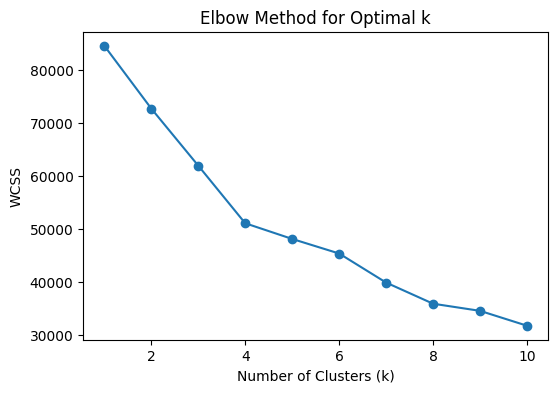

In [21]:
# Plot elbow curve
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [22]:
# Visualize clusters (if 2 features or after PCA)
if X_scaled.shape[1] == 2:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=clusters, palette='viridis')
    plt.title('K-Means Clusters')
    plt.show()
else:
    print("Note: Visualization skipped (data has >2 features). Consider PCA for 2D plotting.")

Note: Visualization skipped (data has >2 features). Consider PCA for 2D plotting.
